# Case Study: ETL of Sales and Payment Behavior in E-Commerce
**Author:** Ignacio Recabal

**Role:** Junior Data Analyst

**Project Approach:** Hybrid (Python for ETL + Power BI for Interactive Dashboard)

---

## 1. Introduction and Scope
This notebook contains the **ETL (Extraction, Transformation, and Loading)** stage of the Olist e-commerce data. Here, we process and normalize transactions to correct duplicates at the order level and structure price segmentation.

The result of this script will be automatically exported to be consumed directly from **Power BI**, where the executive dashboard will be built.

In [ ]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("Entorno optimizado para procesamiento de datos listo.")

Entorno optimizado para procesamiento de datos listo.


In [ ]:
#We create our path and load the Data folder, we apply try-exceed in case the files are not in the path.
base_path = Path("./Data")

try:
    fact = pd.read_csv(base_path / "fact.csv", sep=";")

    payments = pd.read_csv(base_path / "olist_order_payments_dataset.csv", sep="," )

    translate = pd.read_csv( base_path / "product_category_name_translation.csv", sep="," )

    print("Datasets cargados correctamente")

except FileNotFoundError as e:
    print(f"Error al cargar datasets: {e}")

Datasets cargados correctamente


In [ ]:
#We define the variables that we will use during this project.
def audit_nulls(df):
  print(df.isnull().sum())


def audit_column(df, column):
  print(df[column].isnull().sum())


def normalize_columns(df): df.columns = ( df.columns.str.lower().str.replace(" ","_"))

  return df

In [ ]:
#We audit our dataframes and normalize the data.
audit_nulls(fact)
audit_nulls(payments)
audit_nulls(translate)

fact = normalize_columns(fact)
payments = normalize_columns(payments)
translate = normalize_columns(translate)

print("Tus dataframes han sido normalizadas.")


order_id                     0
customer_id              71655
customer_city            71655
product_id                 775
price                        0
freight_value                0
product_category_name     2379
product_weight_kg            0
product_length_cm            0
product_height_cm            0
product_width_cm             0
product_volume_m3            0
dtype: int64
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64
product_category_name            0
product_category_name_english    0
dtype: int64
Tus dataframes han sido normalizadas.


In [ ]:
# In this case, we will audit whether or not there are records in the order_id column for the 2 columns with the highest number of nulls,

mapping_customers = fact.dropna(subset=['customer_id']).set_index('order_id')['customer_id'].to_dict()
mapping_cities = fact.dropna(subset=['customer_city']).set_index('order_id')['customer_city'].to_dict()

fact['customer_id'] = fact['customer_id'].fillna(fact['order_id'].map(mapping_customers))
fact['customer_city'] = fact['customer_city'].fillna(fact['order_id'].map(mapping_cities))

print(f"Nulos remanentes en customer_id: {fact['customer_id'].isnull().sum()}")
print(f"Nulos remanentes en customer_city: {fact['customer_city'].isnull().sum()}")

Nulos remanentes en customer_id: 71655
Nulos remanentes en customer_city: 71655


Null values ​​for `customer_id` could not be retrieved using the mapping performed with `order_id`.

Since the project's primary analysis focuses on payment behavior and credit card usage,
and not on customer-centric metrics,
null values ​​were replaced with a 32-character hash of 0.

I also evaluated retrieving null values ​​for `customer_city`
by mapping to `order_id`, but the number of missing records
remained virtually the same.

Since the primary analysis focused on payment behavior
and overall logistics costs, rather than geographic segmentation,
I decided against artificially manipulating cities to avoid introducing
potentially incorrect information into the model.

In [ ]:
fact["customer_id"] = fact["customer_id"].fillna('0' * 32)
print(f"Nulos restantes en customer_id: {fact['customer_id'].isnull().sum()}")

Nulos restantes en customer_id: 0


In [ ]:
#There were 2379 null values ​​in the product_category_name column, so since we didn't know which product it directly corresponded to, we defined it with "Unclassified".
fact["product_category_name"] = fact["product_category_name"].fillna("Unclassified")

In [ ]:
#There are null values ​​in product_id, so since it is a very sensitive column, we make sure that % they represent in the total data.
audit_nulls(fact)

order_id                     0
customer_id                  0
customer_city            71655
product_id                 775
price                        0
freight_value                0
product_category_name        0
product_weight_kg            0
product_length_cm            0
product_height_cm            0
product_width_cm             0
product_volume_m3            0
dtype: int64


In [ ]:
#We realize that the amount of null data in product_id is not even comparable to 1% of the total data, so we proceed to remove them before exporting to Power BI.
product_id_clean=fact.dropna(subset=["product_id"])
assert product_id_clean["product_id"].isnull().sum() == 0, "Hay nulos en product_id"

print(f"Nulos restantes en product_id: {product_id_clean["product_id"].isnull().sum()}")
print(f"Filas restantes para el analisis:{product_id_clean.shape[0]:,}")

Nulos restantes en product_id: 0
Filas restantes para el analisis:112,650


In [ ]:
#We validate if there is more than one payment method for the same order_id.
payments.groupby("order_id")["payment_type"].nunique().sort_values(ascending=False)

,payment_type
order_id,
34e0517759f61ad4194136f63ab3f3cb,2
34dedd5cb5e0f12df565171392540a8f,2
4f08e1d966e9e49ca0677134ce4c2c57,2
b2f92b2f7047cd8b35580d629d7b3bfb,2
4f0b86c3487e56b6e9594e9dfdb5d70c,2
...,...
564d8bd235927df0c8c8bfe8ff4aee6d,1
564d27104ae4e2c4d3592769b928fee6,1
564cffd60596c7076932fbeadbc7b898,1


In [ ]:
# We order the payment dataset, using first since we assume the highest amount is the primary payment method.
payments_sorted = payments.sort_values(by=["order_id", "payment_value"], ascending=[True, False])
payments_group = (payments_sorted.groupby("order_id") .agg("payment_value": "sum", "payment_type": "first"}).reset_index())

In [ ]:
#In this case, we separate both data frames to avoid causing a granularity problem with groupby.
data_items = product_id_clean.copy()
data_payments = payments_group.copy()

In [ ]:
#In this case, we will paste the product_category_name_english column from the translate dataframe into the main dataframe.
data_items = data_items.merge(translate, on="product_category_name", how="left")
assert "product_category_name_english" in data_items.columns,"product_category_name_english no existe después del merge"
data_items.head(3)

,order_id,customer_id,customer_city,product_id,price,freight_value,product_category_name,product_weight_kg,product_length_cm,product_height_cm,product_width_cm,product_volume_m3,product_category_name_english
0,026a8d09914c519feb34944477b6bd41,47a9d5ffbfeea9fd0290d4c461d7a169,belo horizonte,d2f2c2b94c6ac44ece0bd0dd202c7939,35.99,19.59,moveis_decoracao,1.05,32,12,32,0.0123,furniture_decor
1,04e83658486074318f1a806c19265817,91fd140e38421fcc6f81f31e07d21275,sao paulo,1dfb36d969d347f56f43590ec42c7b8c,159.99,14.06,esporte_lazer,0.90,26,6,13,0.0020,sports_leisure
2,01d0cbd002be92b5a970cb8f233349c2,034c3cb26461c58520139e4efb33ed90,alagoinhas,e2acf075e3634e6f0c26e4e88c1bf9d7,329.90,46.39,moveis_sala,6.75,54,18,53,0.0515,furniture_living_room


In [ ]:
#We analyzed the dataframe again and normalized the new data.
audit_column(data_items,"product_category_name_english")

data_items = normalize_columns(data_items)
data_items.head(3)


1628


,order_id,customer_id,customer_city,product_id,price,freight_value,product_category_name,product_weight_kg,product_length_cm,product_height_cm,product_width_cm,product_volume_m3,product_category_name_english
0,026a8d09914c519feb34944477b6bd41,47a9d5ffbfeea9fd0290d4c461d7a169,belo horizonte,d2f2c2b94c6ac44ece0bd0dd202c7939,35.99,19.59,moveis_decoracao,1.05,32,12,32,0.0123,furniture_decor
1,04e83658486074318f1a806c19265817,91fd140e38421fcc6f81f31e07d21275,sao paulo,1dfb36d969d347f56f43590ec42c7b8c,159.99,14.06,esporte_lazer,0.90,26,6,13,0.0020,sports_leisure
2,01d0cbd002be92b5a970cb8f233349c2,034c3cb26461c58520139e4efb33ed90,alagoinhas,e2acf075e3634e6f0c26e4e88c1bf9d7,329.90,46.39,moveis_sala,6.75,54,18,53,0.0515,furniture_living_room


In [ ]:
#Now that we only want to work with the product names in English, we remove the column we don't need.
data_items.drop(columns=["product_category_name"], inplace=True)

data_items.head(3)

,order_id,customer_id,customer_city,product_id,price,freight_value,product_weight_kg,product_length_cm,product_height_cm,product_width_cm,product_volume_m3,product_category_name_english
0,026a8d09914c519feb34944477b6bd41,47a9d5ffbfeea9fd0290d4c461d7a169,belo horizonte,d2f2c2b94c6ac44ece0bd0dd202c7939,35.99,19.59,1.05,32,12,32,0.0123,furniture_decor
1,04e83658486074318f1a806c19265817,91fd140e38421fcc6f81f31e07d21275,sao paulo,1dfb36d969d347f56f43590ec42c7b8c,159.99,14.06,0.90,26,6,13,0.0020,sports_leisure
2,01d0cbd002be92b5a970cb8f233349c2,034c3cb26461c58520139e4efb33ed90,alagoinhas,e2acf075e3634e6f0c26e4e88c1bf9d7,329.90,46.39,6.75,54,18,53,0.0515,furniture_living_room


In [ ]:
#We've organized it for better readability
cols = data_items.columns.tolist()
cols.remove("product_category_name_english")

cols.insert(cols.index("order_id") + 1, "product_category_name_english")

data_items = data_items[cols]

data_items.isnull().sum()
data_items.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 12 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112650 non-null  object 
 1   product_category_name_english  111022 non-null  object 
 2   customer_id                    112650 non-null  object 
 3   customer_city                  41502 non-null   object 
 4   product_id                     112650 non-null  object 
 5   price                          112650 non-null  float64
 6   freight_value                  112650 non-null  float64
 7   product_weight_kg              112650 non-null  float64
 8   product_length_cm              112650 non-null  int64  
 9   product_height_cm              112650 non-null  int64  
 10  product_width_cm               112650 non-null  int64  
 11  product_volume_m3              112650 non-null  float64
dtypes: float64(4), int64(3), objec

In [ ]:
# We analyze price percentiles to understand the distribution of tickets within the dataset
# and build more consistent segments.

data_payments["payment_value"].quantile([0.25, 0.50, 0.75, 0.90])


,payment_value
0.25,62.010
0.50,105.290
0.75,176.970
0.90,308.243


## Payment Value Segmentation

For this analysis, stable ranges were used with `pd.cut`
instead of dynamic segmentations like `pd.qcut`.

This decision aims to maintain comparable categories over time,
allowing for the analysis of purchasing behavior, logistical impact,
and payment patterns even during promotions, changes in demand,

or the introduction of higher-value products.

## Ticket Distribution

Percentiles of `payment_value` were analyzed
to understand the distribution of amounts paid
per order and to build consistent business segments.

The distribution showed:

- 25% of orders below $65.67 USD
- Median near $114.44 USD
- 75% of orders below $195.39 USD
- 10% of orders above $348.81 USD

Based on this, ranges were defined for commercial and logistical analysis, allowing differentiation between:

- Low-ticket purchases
- Representative average consumption
- High-value orders
- Premium transactions with greater financial and operational impact

In [ ]:
# We'll create price ranges and labels using `pd.cut` to maintain stable and comparable payment segments over time.

# We'll use `float("inf")` instead of a standard range like 3000 or 5000 because if the e-commerce site adds a product at 3050 or 5050, for example, the range won't detect it.

bins = [0,100,200,350,500,1000,float("inf")]

labels =["low", "medium", "high", "premium", "luxury", "ultra luxury",]

data_payments["payment_range"] =pd.cut(data_payments["payment_value"], bins=bins, labels=labels)

In [ ]:
#Once the price range and its labels have been created, we join them to a new table to make it easier to work with.
payment_behavior = (data_payments.groupby(["payment_range","payment_type"],observed=False).agg({"order_id":"count"}).reset_index())

In [ ]:
#una vez unida ambas tablas corroboramos que toda la informacion este correcta.
payment_behavior.sort_values("order_id", ascending=False)


,payment_range,payment_type,order_id
1,low,credit_card,34035
6,medium,credit_card,24615
0,low,boleto,10464
11,high,credit_card,9965
5,medium,boleto,5980
16,premium,credit_card,2855
21,luxury,credit_card,2542
10,high,boleto,2085
4,low,voucher,1905
26,ultra luxury,credit_card,963


In [ ]:
#In this case, we will use .pivot to reorganize the table and ensure that the relevant information remains as rows, columns, and values, making it easier to read.
payment_pivot = payment_behavior.pivot(index="payment_range", columns="payment_type", values="order_id")

print(payment_pivot)


payment_type   boleto  credit_card  debit_card  not_defined  voucher
payment_range                                                       
low             10464        34035         852            0     1905
medium           5980        24615         433            0      874
high             2085         9965         160            0      240
premium           577         2855          38            0       63
luxury            500         2542          29            0       51
ultra luxury      178          963          15            0       18


In [ ]:
# We save the master DataFrame (where fact, payments, and the translation were combined)
# to import it directly into Power BI.

data_items.to_csv("fact_items.csv",index=False,sep=",")

data_payments.to_csv("fact_payments.csv",index=False,sep=",")

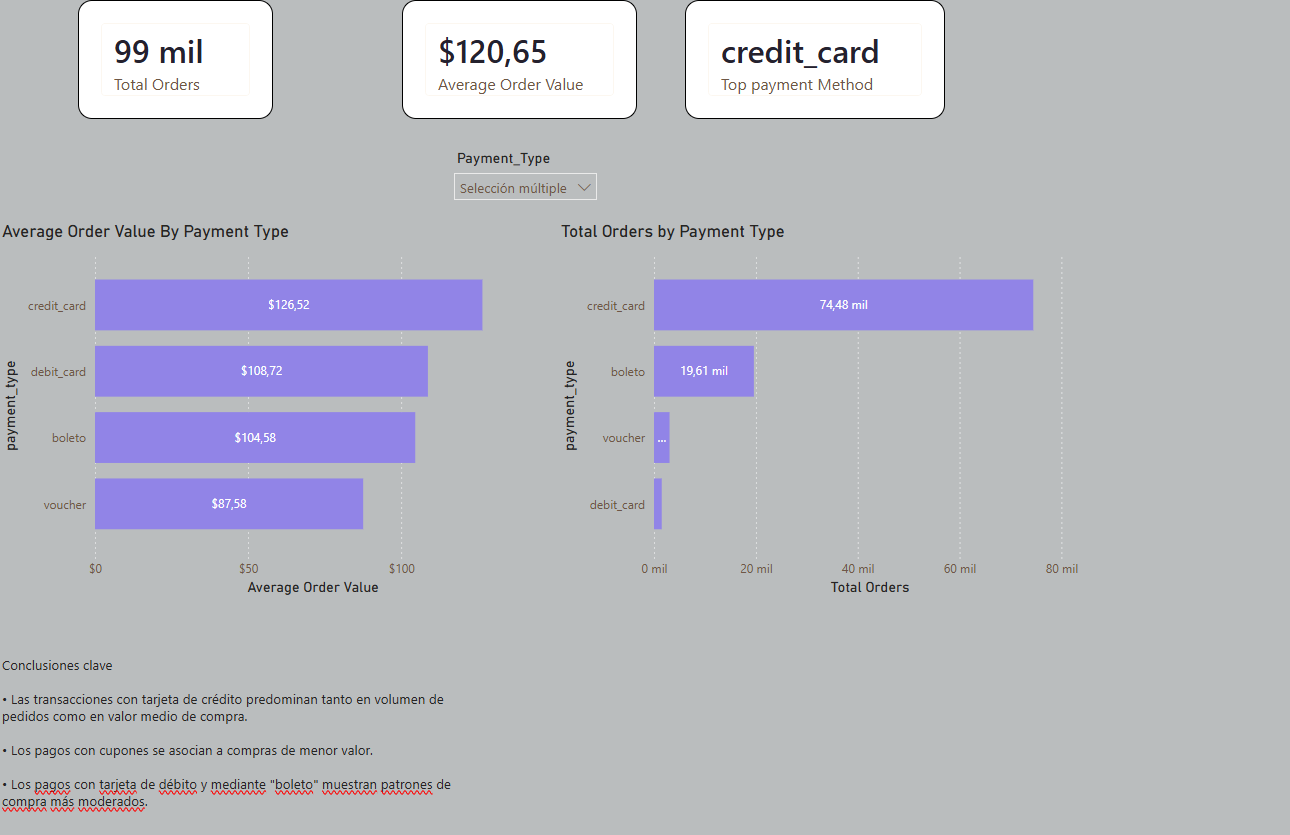

In [ ]:
from IPython.display import Image, display

display(Image(filename='Data/dashboard_payments.png'))